# 04 — EDA: POS_CASH_balance / credit_card_balance / installments_payments

Análisis de las **tablas de comportamiento de pago** de créditos previos en Home Credit.  
Son tablas mensuales que se agregan por SK_ID_PREV → SK_ID_CURR antes de unirse a la tabla principal.

## Estructura
```
previous_application (SK_ID_PREV)
    ├── POS_CASH_balance.csv        (SK_ID_PREV → saldo mensual POS/efectivo)
    ├── credit_card_balance.csv     (SK_ID_PREV → saldo mensual tarjetas)
    └── installments_payments.csv   (SK_ID_PREV → historial de cuotas)
```

## Contenido
1. CSV → Parquet (una sola vez)
2. Carga y estructura de las 3 tablas
3. POS_CASH: DPD (días de mora) vs TARGET
4. installments: comportamiento de pago vs TARGET  
5. credit_card: saldo y mora vs TARGET
6. Aggregaciones a nivel SK_ID_CURR
7. Correlación con TARGET
8. Resumen

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('white')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

COLOR_0 = "#000986"   
COLOR_1 = "#fc1c03"

ROOT      = os.path.abspath(os.path.join('..', '..'))
DATA_RAW  = os.path.join(ROOT, 'data', 'raw')
DATA_PROC = os.path.join(ROOT, 'data', 'processed')

os.makedirs(DATA_PROC, exist_ok=True)

## 1. CSV → Parquet

Estas tablas son grandes (hasta 13.6M filas). El parquet reduce considerablemente el tiempo de lectura.

In [2]:
tables = {
    'pos_cash':     ('POS_CASH_balance.csv',         'pos_cash.parquet'),
    'credit_card':  ('credit_card_balance.csv',      'credit_card.parquet'),
    'installments': ('installments_payments.csv',    'installments.parquet'),
}

for name, (csv_file, parq_file) in tables.items():
    parq_path = os.path.join(DATA_PROC, parq_file)
    if not os.path.exists(parq_path):
        csv_path = os.path.join(DATA_RAW, csv_file)
        print(f'Convirtiendo {csv_file} → parquet ...')
        df = pd.read_csv(csv_path)
        df.to_parquet(parq_path, index=False)
        del df
        gc.collect()
        print(f'  Guardado: {parq_path}')
    else:
        print(f'{parq_file} ya existe.')

Convirtiendo POS_CASH_balance.csv → parquet ...
  Guardado: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed\pos_cash.parquet
Convirtiendo credit_card_balance.csv → parquet ...
  Guardado: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed\credit_card.parquet
Convirtiendo installments_payments.csv → parquet ...
  Guardado: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed\installments.parquet


## 2. Carga y estructura

In [3]:
pos   = pd.read_parquet(os.path.join(DATA_PROC, 'pos_cash.parquet'))
cc    = pd.read_parquet(os.path.join(DATA_PROC, 'credit_card.parquet'))
instal = pd.read_parquet(os.path.join(DATA_PROC, 'installments.parquet'))
train = pd.read_parquet(os.path.join(DATA_PROC, 'app_train.parquet'))[['SK_ID_CURR', 'TARGET']]
prev  = pd.read_parquet(os.path.join(DATA_PROC, 'previous_application.parquet'))[['SK_ID_PREV', 'SK_ID_CURR']]

print(f'POS_CASH       : {pos.shape[0]:>10,} filas × {pos.shape[1]} columnas')
print(f'credit_card    : {cc.shape[0]:>10,} filas × {cc.shape[1]} columnas')
print(f'installments   : {instal.shape[0]:>10,} filas × {instal.shape[1]} columnas')

print('\nPOS_CASH — primeras filas:')
display(pos.head(3))
print('installments — primeras filas:')
display(instal.head(3))
print('credit_card — primeras filas:')
display(cc.head(3))

POS_CASH       : 10,001,358 filas × 8 columnas
credit_card    :  3,840,312 filas × 23 columnas
installments   : 13,605,401 filas × 8 columnas

POS_CASH — primeras filas:


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0


installments — primeras filas:


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000


credit_card — primeras filas:


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0


## 3. POS_CASH: días de mora (SK_DPD) vs TARGET

In [4]:
# Aggregar POS por SK_ID_CURR (vía SK_ID_PREV)
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_SK_DPD_MAX        =('SK_DPD',     'max'),
    POS_SK_DPD_MEAN       =('SK_DPD',     'mean'),
    POS_SK_DPD_DEF_MAX    =('SK_DPD_DEF', 'max'),
    POS_MONTHS_COUNT      =('MONTHS_BALANCE', 'size'),
    POS_MONTHS_MIN        =('MONTHS_BALANCE', 'min'),
).reset_index()

# STATUS de contratos en el último mes
pos_last = pos.sort_values('MONTHS_BALANCE', ascending=False).groupby('SK_ID_CURR').first().reset_index()
pos_agg = pos_agg.merge(pos_last[['SK_ID_CURR', 'NAME_CONTRACT_STATUS']].rename(
    columns={'NAME_CONTRACT_STATUS': 'POS_LAST_STATUS'}), on='SK_ID_CURR', how='left')

# Correlación con TARGET
pos_target = pos_agg.merge(train, on='SK_ID_CURR', how='inner')
global_rate = train['TARGET'].mean()

print('POS_CASH — correlación con TARGET:')
num_feats = ['POS_SK_DPD_MAX', 'POS_SK_DPD_MEAN', 'POS_SK_DPD_DEF_MAX', 'POS_MONTHS_COUNT', 'POS_MONTHS_MIN']
corr_pos = pos_target[num_feats + ['TARGET']].corrwith(pos_target['TARGET']).drop('TARGET')
display(corr_pos.sort_values(key=abs, ascending=False).to_frame('corr'))

POS_CASH — correlación con TARGET:


,corr
POS_MONTHS_MIN,0.055307
POS_MONTHS_COUNT,-0.035632
POS_SK_DPD_DEF_MAX,0.009580
POS_SK_DPD_MEAN,0.005436
POS_SK_DPD_MAX,0.004763


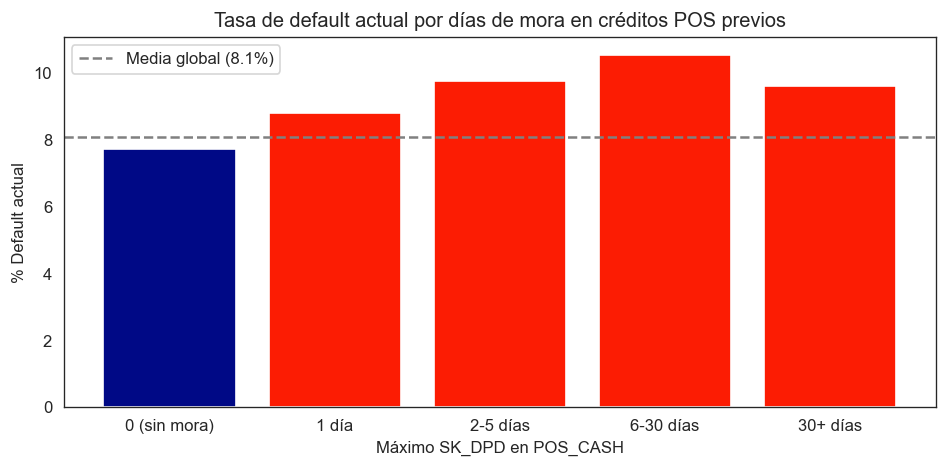

In [5]:
# % Default por DPD máximo en POS_CASH (bins)
pos_target['DPD_BIN'] = pd.cut(pos_target['POS_SK_DPD_MAX'],
                                bins=[-0.1, 0, 1, 5, 30, 1000],
                                labels=['0 (sin mora)', '1 día', '2-5 días', '6-30 días', '30+ días'])
dpd_stats = pos_target.groupby('DPD_BIN', observed=True)['TARGET'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(8, 4))
colors = [COLOR_1 if v > global_rate else COLOR_0 for v in dpd_stats['mean']]
ax.bar(dpd_stats.index, dpd_stats['mean'] * 100, color=colors, edgecolor='white')
ax.axhline(global_rate * 100, color='gray', linestyle='--',
           label=f'Media global ({global_rate*100:.1f}%)')
ax.set_xlabel('Máximo SK_DPD en POS_CASH')
ax.set_ylabel('% Default actual')
ax.set_title('Tasa de default actual por días de mora en créditos POS previos')
ax.legend()
plt.tight_layout()
plt.show()

## 4. installments: comportamiento de pago vs TARGET

Construimos:
- `DPD` = días de mora por cuota = max(0, DAYS_ENTRY_PAYMENT − DAYS_INSTALMENT)
- `DBD` = días antes del vencimiento = max(0, DAYS_INSTALMENT − DAYS_ENTRY_PAYMENT)
- `PAYMENT_RATIO` = AMT_PAYMENT / AMT_INSTALMENT (< 1 → pago parcial)

In [6]:
# Features de comportamiento por cuota
instal['DPD'] = (instal['DAYS_ENTRY_PAYMENT'] - instal['DAYS_INSTALMENT']).clip(lower=0)
instal['DBD'] = (instal['DAYS_INSTALMENT'] - instal['DAYS_ENTRY_PAYMENT']).clip(lower=0)
instal['PAYMENT_RATIO'] = (instal['AMT_PAYMENT'] / instal['AMT_INSTALMENT'].replace(0, np.nan))
instal['PAYMENT_DIFF']  = instal['AMT_INSTALMENT'] - instal['AMT_PAYMENT']

# Aggregar a nivel SK_ID_CURR
instal_agg = instal.groupby('SK_ID_CURR').agg(
    INSTAL_DPD_MEAN          =('DPD',           'mean'),
    INSTAL_DPD_MAX           =('DPD',           'max'),
    INSTAL_DBD_MEAN          =('DBD',           'mean'),
    INSTAL_PAYMENT_RATIO_MEAN=('PAYMENT_RATIO', 'mean'),
    INSTAL_PAYMENT_RATIO_MIN =('PAYMENT_RATIO', 'min'),
    INSTAL_PAYMENT_DIFF_MEAN =('PAYMENT_DIFF',  'mean'),
    INSTAL_PAYMENT_DIFF_MAX  =('PAYMENT_DIFF',  'max'),
    INSTAL_COUNT             =('SK_ID_PREV',    'count'),
).reset_index()

# Correlación con TARGET
instal_target = instal_agg.merge(train, on='SK_ID_CURR', how='inner')
num_feats_instal = [c for c in instal_agg.columns if c != 'SK_ID_CURR']
corr_instal = instal_target[num_feats_instal + ['TARGET']].corrwith(instal_target['TARGET']).drop('TARGET')
corr_instal = corr_instal.sort_values(key=abs, ascending=False)

print('installments — correlación con TARGET:')
display(corr_instal.to_frame('corr'))

installments — correlación con TARGET:


,corr
INSTAL_PAYMENT_RATIO_MIN,-0.045650
INSTAL_PAYMENT_DIFF_MEAN,0.029339
INSTAL_DBD_MEAN,-0.021116
INSTAL_COUNT,-0.021096
INSTAL_PAYMENT_DIFF_MAX,0.019144
INSTAL_DPD_MEAN,0.008937
INSTAL_DPD_MAX,0.003841
INSTAL_PAYMENT_RATIO_MEAN,0.001366


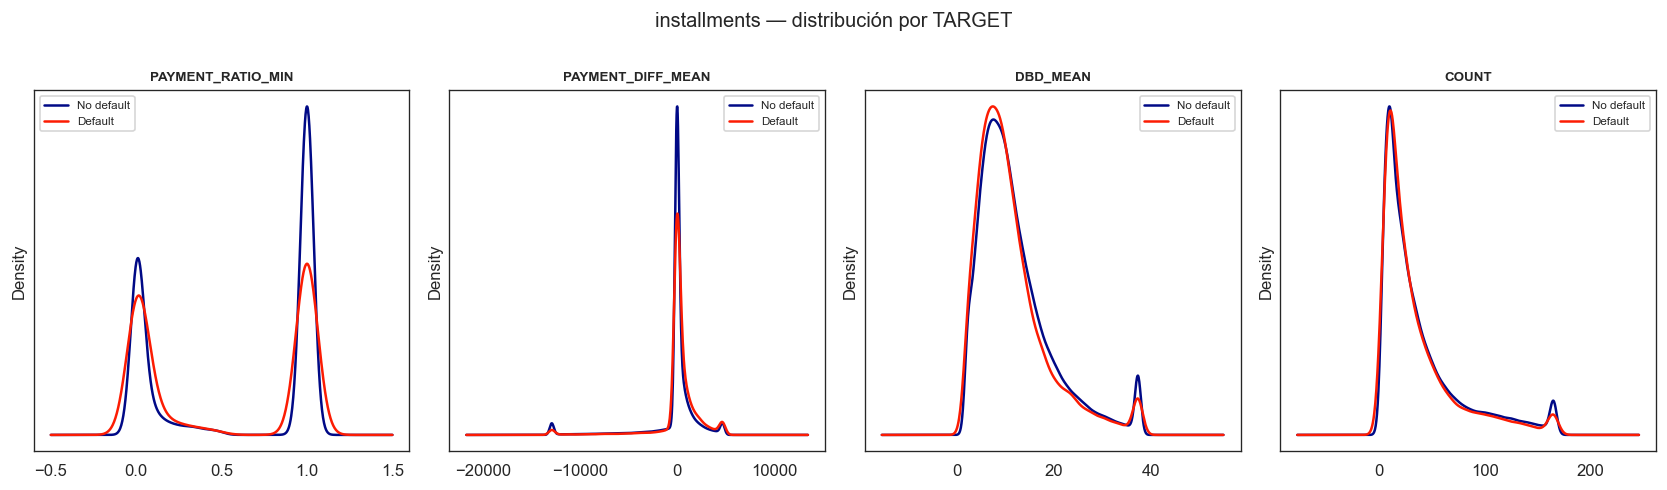

In [7]:
# KDE: DPD y PAYMENT_RATIO por TARGET
df0 = instal_target[instal_target['TARGET'] == 0]
df1 = instal_target[instal_target['TARGET'] == 1]

top_instal = corr_instal.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, col in enumerate(top_instal):
    ax = axes[i]
    lo = instal_target[col].quantile(0.02)
    hi = instal_target[col].quantile(0.98)
    s0 = df0[col].clip(lo, hi).dropna()
    s1 = df1[col].clip(lo, hi).dropna()
    if len(s0) > 10 and len(s1) > 10:
        s0.plot.kde(ax=ax, color=COLOR_0, label='No default', linewidth=1.5)
        s1.plot.kde(ax=ax, color=COLOR_1, label='Default', linewidth=1.5)
    ax.set_title(col.replace('INSTAL_', ''), fontsize=8, fontweight='bold')
    ax.set_yticks([])
    ax.legend(fontsize=7)

plt.suptitle('installments — distribución por TARGET', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 5. credit_card: saldo y mora vs TARGET

In [8]:
# Aggregar credit_card a nivel SK_ID_CURR
cc_agg = cc.groupby('SK_ID_CURR').agg(
    CC_AMT_BALANCE_MEAN     =('AMT_BALANCE',           'mean'),
    CC_AMT_BALANCE_MAX      =('AMT_BALANCE',           'max'),
    CC_SK_DPD_MAX           =('SK_DPD',                'max'),
    CC_SK_DPD_MEAN          =('SK_DPD',                'mean'),
    CC_SK_DPD_DEF_MAX       =('SK_DPD_DEF',            'max'),
    CC_MONTHS_COUNT         =('MONTHS_BALANCE',        'size'),
    CC_AMT_DRAWINGS_MEAN    =('AMT_DRAWINGS_CURRENT',  'mean'),
    CC_AMT_PAYMENT_MEAN     =('AMT_PAYMENT_CURRENT',   'mean'),
).reset_index()

# Utilización de límite de crédito: saldo / límite
cc['UTILIZATION'] = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
cc_agg['CC_UTILIZATION_MEAN'] = cc.groupby('SK_ID_CURR')['UTILIZATION'].mean().values

# Correlación con TARGET
cc_target = cc_agg.merge(train, on='SK_ID_CURR', how='inner')
num_feats_cc = [c for c in cc_agg.columns if c != 'SK_ID_CURR']
corr_cc = cc_target[num_feats_cc + ['TARGET']].corrwith(cc_target['TARGET']).drop('TARGET')
corr_cc = corr_cc.sort_values(key=abs, ascending=False)

print('credit_card — correlación con TARGET:')
display(corr_cc.to_frame('corr'))

credit_card — correlación con TARGET:


,corr
CC_UTILIZATION_MEAN,0.135560
CC_AMT_BALANCE_MEAN,0.087177
CC_AMT_BALANCE_MAX,0.068798
CC_MONTHS_COUNT,-0.060481
CC_AMT_DRAWINGS_MEAN,0.058732
CC_SK_DPD_DEF_MAX,0.007089
CC_SK_DPD_MAX,-0.005975
CC_AMT_PAYMENT_MEAN,0.005274
CC_SK_DPD_MEAN,-0.003195


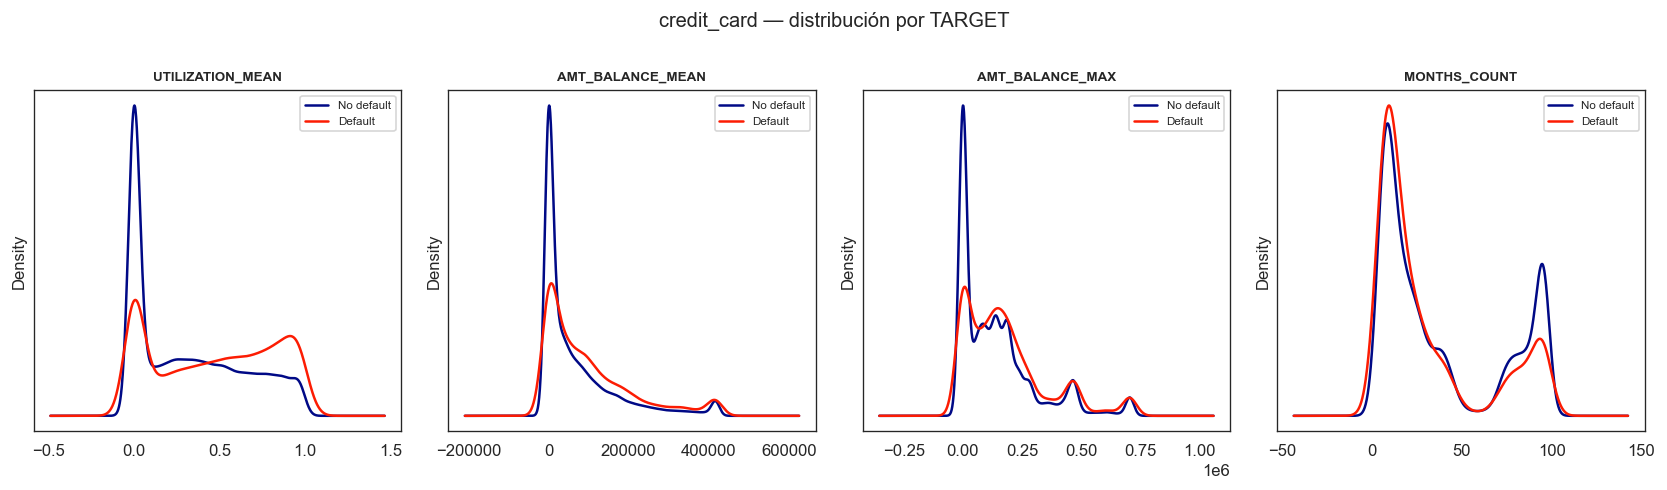

In [9]:
# KDE: top features credit_card
df0 = cc_target[cc_target['TARGET'] == 0]
df1 = cc_target[cc_target['TARGET'] == 1]
top_cc = corr_cc.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, col in enumerate(top_cc):
    ax = axes[i]
    lo = cc_target[col].quantile(0.02)
    hi = cc_target[col].quantile(0.98)
    s0 = df0[col].clip(lo, hi).dropna()
    s1 = df1[col].clip(lo, hi).dropna()
    if len(s0) > 10 and len(s1) > 10:
        s0.plot.kde(ax=ax, color=COLOR_0, label='No default', linewidth=1.5)
        s1.plot.kde(ax=ax, color=COLOR_1, label='Default', linewidth=1.5)
    ax.set_title(col.replace('CC_', ''), fontsize=8, fontweight='bold')
    ax.set_yticks([])
    ax.legend(fontsize=7)

plt.suptitle('credit_card — distribución por TARGET', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Comparativo de correlación entre tablas

In [10]:
# Compilar las top 3 features de cada tabla (balance tables)
top_per_table = {
    'POS_CASH':     corr_pos.sort_values(key=abs, ascending=False).head(3),
    'installments': corr_instal.head(3),
    'credit_card':  corr_cc.head(3),
}

rows = []
for table, corr_ser in top_per_table.items():
    for feat, corr_val in corr_ser.items():
        rows.append({'Tabla': table, 'Feature': feat, 'Corr con TARGET': round(corr_val, 4)})

summary_df = pd.DataFrame(rows)
print('Top 3 features de cada tabla (correlación con TARGET):')
display(summary_df)

Top 3 features de cada tabla (correlación con TARGET):


,Tabla,Feature,Corr con TARGET
0,POS_CASH,POS_MONTHS_MIN,0.0553
1,POS_CASH,POS_MONTHS_COUNT,-0.0356
2,POS_CASH,POS_SK_DPD_DEF_MAX,0.0096
3,installments,INSTAL_PAYMENT_RATIO_MIN,-0.0457
4,installments,INSTAL_PAYMENT_DIFF_MEAN,0.0293
5,installments,INSTAL_DBD_MEAN,-0.0211
6,credit_card,CC_UTILIZATION_MEAN,0.1356
7,credit_card,CC_AMT_BALANCE_MEAN,0.0872
8,credit_card,CC_AMT_BALANCE_MAX,0.0688


## 7. Resumen — candidatas de balance tables para feature engineering

In [11]:
print('Features seleccionadas para notebook 05:')
selected = [
    # installments
    ('INSTAL_DPD_MEAN',           'Días de mora promedio en cuotas'),
    ('INSTAL_PAYMENT_RATIO_MEAN', 'Ratio pago/cuota promedio (< 1 → pago parcial)'),
    ('INSTAL_PAYMENT_DIFF_MEAN',  'Diferencia cuota − pago promedio'),
    # POS_CASH
    ('POS_SK_DPD_MAX',            'Máximo días de mora en POS'),
    ('POS_MONTHS_COUNT',          'Número de registros mensuales POS'),
    # credit_card
    ('CC_AMT_BALANCE_MEAN',       'Saldo promedio en tarjetas de crédito'),
    ('CC_SK_DPD_MAX',             'Máximo días de mora en tarjetas'),
    ('CC_UTILIZATION_MEAN',       'Utilización promedio del límite de crédito'),
]
for feat, desc in selected:
    print(f'  {feat:<35s} ← {desc}')

Features seleccionadas para notebook 05:
  INSTAL_DPD_MEAN                     ← Días de mora promedio en cuotas
  INSTAL_PAYMENT_RATIO_MEAN           ← Ratio pago/cuota promedio (< 1 → pago parcial)
  INSTAL_PAYMENT_DIFF_MEAN            ← Diferencia cuota − pago promedio
  POS_SK_DPD_MAX                      ← Máximo días de mora en POS
  POS_MONTHS_COUNT                    ← Número de registros mensuales POS
  CC_AMT_BALANCE_MEAN                 ← Saldo promedio en tarjetas de crédito
  CC_SK_DPD_MAX                       ← Máximo días de mora en tarjetas
  CC_UTILIZATION_MEAN                 ← Utilización promedio del límite de crédito


---
**Próximo notebook**: `05_feature_engineering.ipynb` — construcción del dataset final con ≤30 features.